
# Příprava dat a TF-IDF
$$\text{TF} = \frac{\text{četnost slova v dokumentu}}{\text{rozsah dokumentu}} \quad \text{IDF} = \log\left(\frac{\text{celkový počet dokumentů}}{\text{počet dokumentů se slovem} + 1}\right)$$

Prvek na pozici $(i, j)$ v matici reprezentuje výslednou váhu konkrétního slova v konkrétním dokumentu:

$$\text{TF-IDF}_{i, j} = \text{TF}_{i, j} \cdot \text{IDF}_j$$

$$X = \begin{array}{cc} & \begin{matrix} \text{slovo}_1 & \text{slovo}_2 & \cdots & \text{slovo}_n \end{matrix} \\ \begin{matrix} \text{dokument}_1 \\ \text{dokument}_2 \\ \vdots \\ \text{dokument}_m \end{matrix} & \begin{pmatrix} \text{TF-IDF}_{1,1} & \text{TF-IDF}_{1,2} & \cdots & \text{TF-IDF}_{1,n} \\ \text{TF-IDF}_{2,1} & \text{TF-IDF}_{2,2} & \cdots & \text{TF-IDF}_{2,n} \\ \vdots & \vdots & \ddots & \vdots \\ \text{TF-IDF}_{m,1} & \text{TF-IDF}_{m,2} & \cdots & \text{TF-IDF}_{m,n} \end{pmatrix} \end{array}$$

### Hustá matice
Každá pozice v matici obsahuje konkrétní hodnotu, včetně nulových prvků:

$$\begin{pmatrix} 0.45 & 0.00 & 0.00 \\ 0.00 & 0.82 & 0.00 \\ 0.00 & 0.00 & 0.00 \end{pmatrix}$$

### Řídká matice
Ukládá pouze nenulové hodnoty a jejich přesné souřadnice (indexy sloupů a řádků), což výrazně šetří operační paměť:

* **Hodnoty:** `[0.45, 0.82]`
* **Sloupce:** `[0, 1]`
* **Řádky:** `[0, 1]`

---



# Logistická regrese v klasifikaci textu

Logistická regrese odhaduje pravděpodobnost příslušnosti vzorku ke třídě transformací lineární kombinace příznaků pomocí sigmoidní funkce.

## Definice modelu

Vstupem je matice příznaků $X$ ($m \times n$) a vektor tříd $y \in \{0, 1\}$. Lineární skóre $z$ je definováno jako:

$$z = w \cdot X + b$$

Kde $w$ je vektor vah jednotlivých slov a $b$ je intercept (bias).

Predikovaná pravděpodobnost $\hat{y}$ se spočte jako:

$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

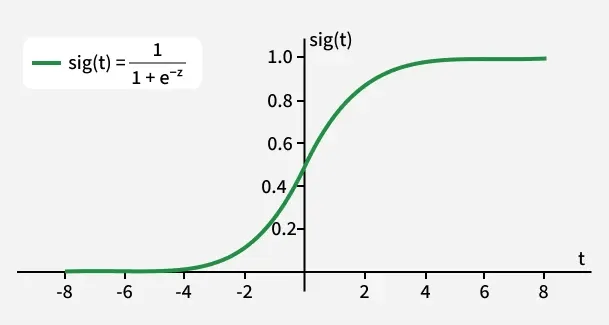

Klasifikační pravidlo:
$$\text{Třída} = \begin{cases} 1 & \text{pokud } \hat{y} \ge 0.5 \\ 0 & \text{pokud } \hat{y} < 0.5 \end{cases}$$

## Účelová funkce s $L_2$ regularizací

Parametry se optimalizují minimalizací binární křížové entropie penalizované za velikost vah ($L_2$ regularizace):

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right] + \frac{\lambda}{2m} \sum_{j=1}^{n} w_j^2$$

* **Log-Loss (první člen):** Penalizuje odchylku predikce od skutečné třídy. S rostoucí chybou roste penalizace logaritmicky.
* **Regularizace (druhý člen):** Koeficient $\lambda$ řídí penalizaci vysokých hodnot $w_j$. Tím omezuje dominanci jednotlivých slov a snižuje riziko přetrénování.

## Optimalizace parametrů

Nalezení minimální hodnoty $J(w, b)$ probíhá pomocí gradientního sestupu. V každém kroku se parametry aktualizují na základě parciálních derivací a rychlosti učení $\alpha$:

$$w := w - \alpha \frac{\partial J}{\partial w}$$
$$b := b - \alpha \frac{\partial J}{\partial b}$$

# Support Vector Machines (SVM) v klasifikaci textu

Support Vector Machines (SVM) vyhledává v prostoru příznaků optimální rozhodovací nadrovinu, která maximalizuje geometrický odstup mezi třídami.

## Definice nadroviny

Vstupem je matice příznaků $X$ ($m \times n$) a vektor cílových tříd $y^{(i)} \in \{-1, 1\}$. Rozhodovací nadrovina je definována rovnicí:

$$w \cdot x + b = 0$$

Kde $w$ je normálový vektor určující orientaci nadroviny a $b$ je intercept (bias) určující její posun.

Klasifikační pravidlo:

$$\hat{y} = \text{sign}(w \cdot x + b)$$

## Princip maximálního okraje (Margin)

Hranice pro jednotlivé třídy jsou definovány body, které leží nejblíže rozhodovací nadrovině (podpůrné vektory):

* Pro třídu $y = 1$: $w \cdot x + b = 1$
* Pro třídu $y = -1$: $w \cdot x + b = -1$

Šířka okraje mezi těmito hranicemi je vyjádřena jako:

$$\text{Margin} = \frac{2}{\|w\|}$$

Algoritmus minimalizací $\|w\|$ maximalizuje tuto šířku.

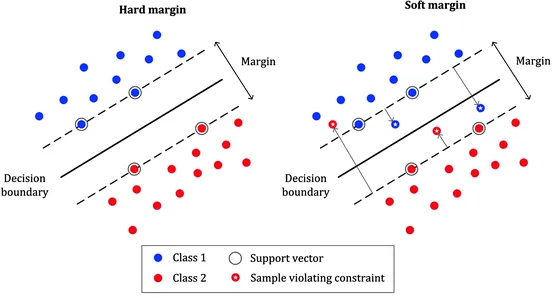

## Závěsová ztráta (Hinge Loss)

Pro penalizaci chyb a překročení okraje se používá funkce Hinge Loss:

$$L(x, y) = \max(0, 1 - y \cdot (w \cdot x + b))$$

* **$y \cdot (w \cdot x + b) \ge 1$:** Bod je klasifikován správně a leží vně okraje. Ztráta je $0$.
* **$0 \le y \cdot (w \cdot x + b) < 1$:** Bod je klasifikován správně, ale zasahuje do okraje. Model obdrží malou penalizaci.
* **$y \cdot (w \cdot x + b) < 0$:** Bod je klasifikován chybně. Penalizace roste lineárně s narůstající vzdáleností od okraje.

## Účelová funkce

Celková účelová funkce kombinuje maximalizaci okraje a penalizaci chyb:

$$J(w, b) = \frac{1}{2} \|w\|^2 + C \cdot \frac{1}{m} \sum_{i=1}^{m} \max\left(0, 1 - y^{(i)} (w \cdot X^{(i)} + b)\right)$$

Hyperparametr $C$ určuje váhu penalizace chyb vůči šířce okraje.


<https://github.com/vojtajez/algo_project>

In [1]:
from data_prep import tokenize, vocabulary, tfidf_sparse, plot_sentiment_distribution, plot_cloud, bar_top_words, plot_confusion_matrix
from logistic_regression import train_lr, predict_lr, compute_loss, predict_new_sentence
from svm import train_svm, predict_svm
import pandas as pd
import numpy as np

data = pd.read_csv("data.csv")
print(data.head())

                                            Sentence Sentiment
0  The GeoSolutions technology will leverage Bene...  positive
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative
2  For the last quarter of 2010 , Componenta 's n...  positive
3  According to the Finnish-Russian Chamber of Co...   neutral
4  The Swedish buyout firm has sold its remaining...   neutral


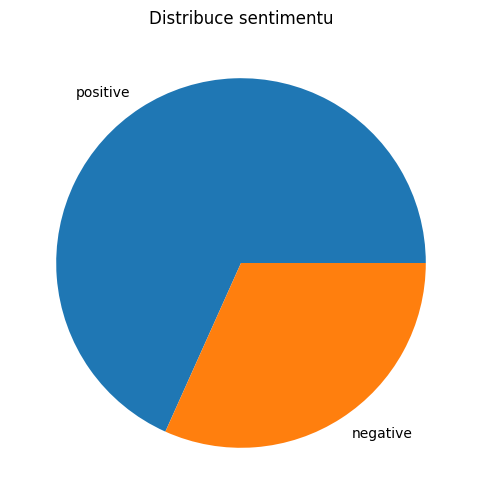

                                            Sentence Sentiment  Label
0  By 14:29 CET on Monday , shares in Bavarian No...  positive      1
1  The liquidity providing was interrupted on May...  negative      0
2                                    $SPY weak close  negative      0
3  Finnish Outokumpu Technology has been awarded ...  positive      1
4  Satama 's net sales would be higher than the y...  positive      1


In [2]:
data = data[data["Sentiment"] != "neutral"]
data = data.sample(frac=1).reset_index(drop=True)
data['Label'] = data['Sentiment'].apply(lambda x: 1 if x == 'positive' else 0)
plot_sentiment_distribution(data)
print(data.head())

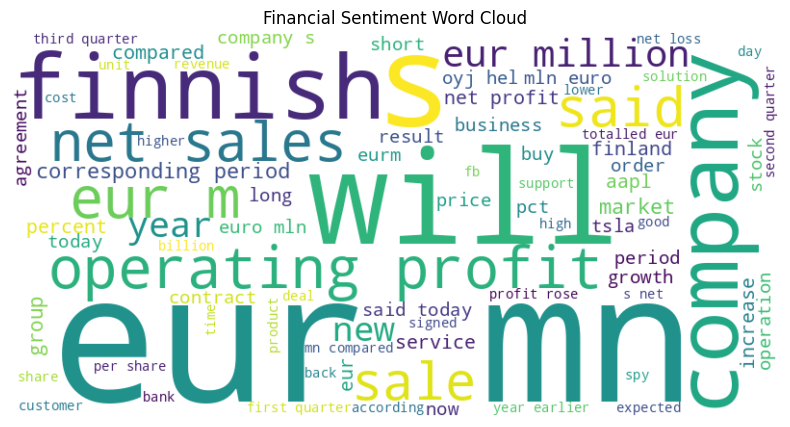

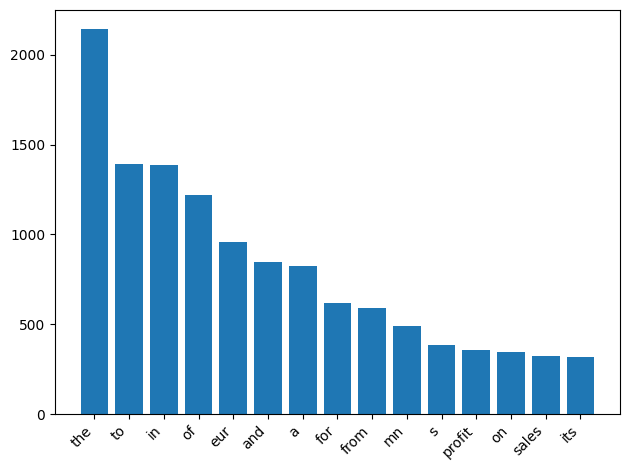

In [3]:
data["Cleaned_tokens"] = data["Sentence"].apply(tokenize)
corpus = data["Cleaned_tokens"].tolist()

plot_cloud(corpus)
bar_top_words(15, corpus)
#Potreba ocistit o stop words

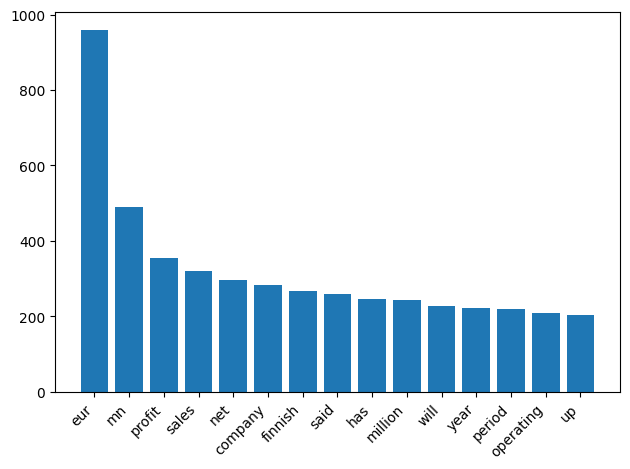

In [4]:
stop_words = ["the", "is", "at", "which", "on", "and", "a", "to", "in", "of", "for", "with", "as", "by", "that", "this", "it", "from", "are", "was", "be", "or", "an", "not", "all", "but", "if", "they", "their", "we", "he", "she", "my", "your", "his", "her", "its", "our", "us", "them", "what", "who", "whom", "which", "whose", "when", "where", "why", "how", "s"]

corpus = [[token for token in doc if token not in stop_words] for doc in corpus]
bar_top_words(15, corpus)

In [5]:
split_idx = int(len(corpus) * 0.8)

X_train = corpus[:split_idx] 
X_test = corpus[split_idx:]
y_train = data["Label"][:split_idx].to_numpy()
y_test = data["Label"][split_idx:].to_numpy()

train_vocab = vocabulary(X_train)

train_tfidf, idf = tfidf_sparse(X_train, train_vocab)
test_tfidf, _ = tfidf_sparse(X_test, train_vocab, idf)

In [6]:
learning_rate = 0.1
epochs = 30_000
lambda_reg = 0.1

weight_0 = len(y_train) / (2 * np.sum(y_train == 0))
weight_1 = len(y_train) / (2 * np.sum(y_train == 1))


weights, bias = train_lr(train_tfidf, np.array(y_train), learning_rate, epochs, lambda_reg, weight_0, weight_1)

Epoch 0, Loss: 0.6931
Epoch 3000, Loss: 0.4983
Epoch 6000, Loss: 0.4042
Epoch 9000, Loss: 0.3460
Epoch 12000, Loss: 0.3057
Epoch 15000, Loss: 0.2758
Epoch 18000, Loss: 0.2526
Epoch 21000, Loss: 0.2340
Epoch 24000, Loss: 0.2186
Epoch 27000, Loss: 0.2058


In [7]:
y_probs = predict_lr(test_tfidf, weights, bias)
test_loss = compute_loss(y_test, y_probs)

y_classes = (y_probs >= 0.5).astype(int)
accuracy = np.mean(y_classes == y_test)

print(f"Test Loss (LogLoss): {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2%}")

Test Loss (LogLoss): 0.3896
Test Accuracy: 85.08%


In [8]:
print(predict_new_sentence("The unexpected resignation of the CEO caused a sharp drop in share prices.", train_vocab,weights, bias, idf))

0.38982388515670047


In [9]:
sorted_indices = np.argsort(weights)
top_positive_indices = sorted_indices[-10:]
top_negative_indices = sorted_indices[:10]
print("Top 10 Positive Words: ")
for idx in top_positive_indices[::-1]:
    print(f"  {train_vocab[idx]}: {weights[idx]:.4f}")

print("Top 10 Negative Words: ")
for idx in top_negative_indices:
    print(f"  {train_vocab[idx]}: {weights[idx]:.4f}")

Top 10 Positive Words: 
  rose: 4.7317
  up: 4.2812
  increased: 3.5847
  increase: 3.4907
  buy: 2.6168
  grew: 2.5669
  long: 2.4813
  improved: 2.3918
  rise: 2.2402
  positive: 2.1890
Top 10 Negative Words: 
  down: -6.6602
  decreased: -6.1603
  fell: -4.5902
  lower: -4.0691
  short: -3.0762
  fall: -3.0467
  cut: -2.6925
  weak: -2.5537
  declined: -2.5198
  dropped: -2.4694


Precision: 0.8838
Recall: 0.9091
F1 Score: 0.8963


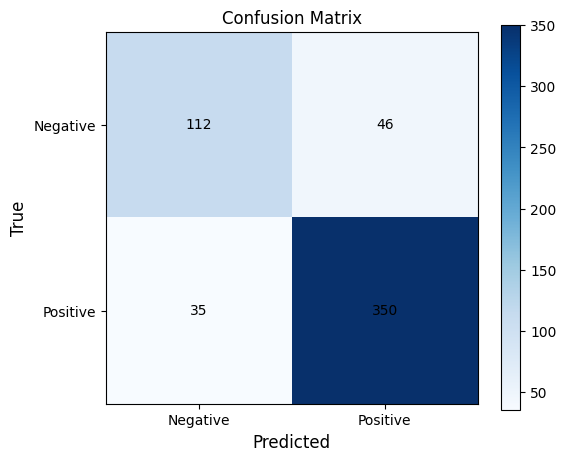

In [10]:
plot_confusion_matrix(y_test, y_classes)

Epoch 0, Loss: 1.000000000004326
Epoch 10000, Loss: 0.6142710205526647
Epoch 20000, Loss: 0.41603134047177504
Epoch 30000, Loss: 0.3062632881343918
Epoch 40000, Loss: 0.23999514330006344
Epoch 50000, Loss: 0.1962285419592132
Epoch 60000, Loss: 0.16439765837364315
Epoch 70000, Loss: 0.14013295302733023
Epoch 80000, Loss: 0.12201440127933134
Epoch 90000, Loss: 0.10809206183985984
SVM Test Accuracy: 84.71%
Precision: 0.8794
Recall: 0.9091
F1 Score: 0.8940


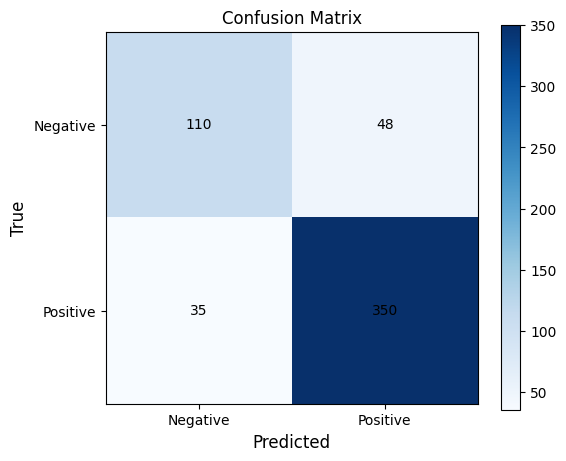

In [11]:
learning_rate = 0.01
epochs = 100_000
lambda_reg = 0.00001


w_svm, b_svm = train_svm(train_tfidf, np.array(y_train), learning_rate, epochs, lambda_reg, weight_0, weight_1,logging=True)

y_svm = predict_svm(test_tfidf, w_svm, b_svm)
print(f"SVM Test Accuracy: {np.mean(y_svm == y_test):.2%}")
plot_confusion_matrix(y_test, y_svm)

In [12]:
sorted_indices = np.argsort(w_svm)
top_positive_indices = sorted_indices[-10:]
top_negative_indices = sorted_indices[:10]
print("Top 10 Positive Words: ")
for idx in top_positive_indices[::-1]:
    print(f"  {train_vocab[idx]}: {w_svm[idx]:.4f}")

print("Top 10 Negative Words: ")
for idx in top_negative_indices:
    print(f"  {train_vocab[idx]}: {w_svm[idx]:.4f}")

Top 10 Positive Words: 
  rose: 3.0365
  up: 2.8276
  increased: 2.3785
  increase: 2.1589
  grew: 1.6131
  higher: 1.4808
  improved: 1.4692
  buy: 1.4564
  narrowed: 1.4299
  positive: 1.2937
Top 10 Negative Words: 
  down: -3.7347
  decreased: -3.6157
  fell: -2.9529
  lower: -2.4364
  short: -2.0773
  fall: -1.9059
  declined: -1.8927
  cut: -1.8047
  dropped: -1.8025
  slipped: -1.6662


LA Test Accuracy: 71.82%
Precision: 0.9113
Recall: 0.6675
F1 Score: 0.7706


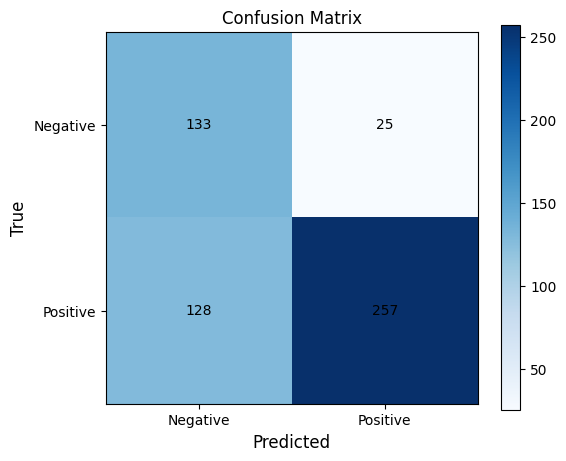

In [13]:
train_tfidf = train_tfidf.tocsr()
test_tfidf = test_tfidf.tocsr()

avg_pos = np.asarray(train_tfidf[y_train == 1].mean(axis=0)).flatten()
avg_neg = np.asarray(train_tfidf[y_train == 0].mean(axis=0)).flatten()

scores_pos = test_tfidf.dot(avg_pos)
scores_neg = test_tfidf.dot(avg_neg)

y_pred_la = np.where(scores_pos > scores_neg, 1, 0)
accuracy_la = np.mean(y_pred_la == y_test)
print(f"LA Test Accuracy: {accuracy_la:.2%}")
plot_confusion_matrix(y_test, y_pred_la)